# Test Nearest Ocean Point and Altitude Correction, which is more reliable


Air temperature: `CaSR` vs `CaSR ocean point` vs `CaSR altitude correction`, at Pam Rocks.

How much cooler per km? 

See: https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2019EA000984. It's best to try 4.5 degrees and 6.5 degrees according to the paper.



## Data Extraction


It's best to extract: `Nearest Ocean Point`, `Nearest 4 points` from `CaSR` and `Obs Data` at Pam Rocks and Sand Heads.

### Nearest Point Grid Number

Recall that: 

```
====================================================================================================
Pam Rocks
NEMO target: y=502, x=341
====================================================================================================

********** 4 atmospheric points actually USED **********

source 2: (ilat, ilon)=(  57,   36)   lat= 49.402325   lon= 236.736679   weight=0.0239716401
source 4: (ilat, ilon)=(  57,   37)   lat= 49.441509   lon= 236.860794   weight=0.0047739371
source 1: (ilat, ilon)=(  58,   36)   lat= 49.483242   lon= 236.676086   weight=0.8099528243
source 3: (ilat, ilon)=(  58,   37)   lat= 49.522491   lon= 236.800385   weight=0.1613015984

```



The 'reliable' grid point lies in the South, which is `(ilat, ilon)=(  56,   35)   lat= 49.282116   lon= 236.673340   neighbor_of=[2]`. The nearest grid point to Pam Rocks in CaSR is `source 1: (ilat, ilon)=(  58,   36)   lat= 49.483242   lon= 236.676086   weight=0.8099528243`.

Also for `Sand Heads`:

```
Station coordinate: lat=49.107586, lon=-123.30203
================================================================================
Sand Heads
NEMO target index: y=428, x=293
Atmospheric source grid: nlat=105, nlon=70
================================================================================
source 1: src=  3815, (ilat, ilon)=(  54,   34), lat= 49.081009, lon= 236.670670, weight=0.5675647174
source 2: src=  3885, (ilat, ilon)=(  55,   34), lat= 49.161884, lon= 236.610321, weight=0.1233862179
source 3: src=  3816, (ilat, ilon)=(  54,   35), lat= 49.120274, lon= 236.793869, weight=0.2538607824
source 4: src=  3886, (ilat, ilon)=(  55,   35), lat= 49.201210, lon= 236.733704, weight=0.0551882822
--------------------------------------------------------------------------------
sum(weights) = 1.000000000000
```

See https://github.com/SalishSeaCast/analysis-junqi/blob/main/Analysis_Atmospheric_Forcing/Analysis_forcing_comparison/Analysis_weights/Fjords.ipynb.

Save to `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Analysis_Fjords/Data_CaSR`



### Weight-corrected Grid Number

In [1]:
# Track function

import xarray as xr
import numpy as np


# ============================================================
# Weight files
# ============================================================

path_weights_casr = '/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Data_weights/weights-CaSR_202108_temp_corrected.nc'

ds_weights_casr = xr.open_dataset(path_weights_casr)



# ============================================================
# Stations: NEMO T-grid index
# ============================================================

stations = {
    'Pam Rocks': {
        'y': 502,
        'x': 341,
        'lat': 49.487434,
        'lon': -123.30153,
    },

    'Sand Heads': {
        'y': 428,
        'x': 293,
        'lat': 49.107586,
        'lon': -123.30203,
    },
}


# ============================================================
# Function
# ============================================================

def print_atmos_source_points(weights, y, x, name=None):
    """
    Print the atmospheric grid points used to interpolate
    one NEMO target grid point (y, x).

    Parameters
    ----------
    weights : xr.Dataset
        NEMO atmospheric interpolation weights file.
        Must contain:
            nav_lat(lat, lon)
            nav_lon(lat, lon)
            src01..src04(y, x)
            wgt01..wgt04(y, x)

    y, x : int
        Zero-based Python indices of the NEMO target grid point.

    name : str, optional
        Name of the target point, for display.
    """

    nlat = weights.sizes["lat"]
    nlon = weights.sizes["lon"]

    if name is None:
        name = "NEMO point"

    print("=" * 80)
    print(f"{name}")
    print(f"NEMO target index: y={y}, x={x}")
    print(f"Atmospheric source grid: nlat={nlat}, nlon={nlon}")
    print("=" * 80)

    weight_sum = 0.0

    for k in range(1, 5):

        src_name = f"src0{k}"
        wgt_name = f"wgt0{k}"

        # ----------------------------------------------------
        # src is Fortran 1-based linear index
        # ----------------------------------------------------
        src = int(weights[src_name].isel(y=y, x=x).item())
        wgt = float(weights[wgt_name].isel(y=y, x=x).item())

        # Fortran 1-based -> Python 0-based
        idx = src - 1

        # Reverse:
        #
        # Fortran:
        #     src = i + nlon * (j - 1)
        #
        # Python:
        #     idx = ilat * nlon + ilon
        #
        ilat = idx // nlon
        ilon = idx % nlon

        # source atmospheric coordinates
        atmos_lat = float(
            weights["nav_lat"].isel(lat=ilat, lon=ilon).item()
        )

        atmos_lon = float(
            weights["nav_lon"].isel(lat=ilat, lon=ilon).item()
        )

        weight_sum += wgt

        print(
            f"source {k}: "
            f"src={src:6d}, "
            f"(ilat, ilon)=({ilat:4d}, {ilon:4d}), "
            f"lat={atmos_lat:10.6f}, "
            f"lon={atmos_lon:11.6f}, "
            f"weight={wgt:.10f}"
        )

    print("-" * 80)
    print(f"sum(weights) = {weight_sum:.12f}")
    print()

# ============================================================
# CaSR
# ============================================================

print("\n\n#################### CaSR ####################\n")

for station_name, station in stations.items():

    print(
        f"Station coordinate: "
        f"lat={station['lat']}, lon={station['lon']}"
    )

    print_atmos_source_points(
        ds_weights_casr,
        y=station["y"],
        x=station["x"],
        name=station_name,
    )




#################### CaSR ####################

Station coordinate: lat=49.487434, lon=-123.30153
Pam Rocks
NEMO target index: y=502, x=341
Atmospheric source grid: nlat=105, nlon=70
source 1: src=  4025, (ilat, ilon)=(  57,   34), lat= 49.323540, lon= 236.489075, weight=1.0000000000
source 2: src=  4025, (ilat, ilon)=(  57,   34), lat= 49.323540, lon= 236.489075, weight=0.0000000000
source 3: src=  4025, (ilat, ilon)=(  57,   34), lat= 49.323540, lon= 236.489075, weight=0.0000000000
source 4: src=  4025, (ilat, ilon)=(  57,   34), lat= 49.323540, lon= 236.489075, weight=0.0000000000
--------------------------------------------------------------------------------
sum(weights) = 1.000000000000

Station coordinate: lat=49.107586, lon=-123.30203
Sand Heads
NEMO target index: y=428, x=293
Atmospheric source grid: nlat=105, nlon=70
source 1: src=  3815, (ilat, ilon)=(  54,   34), lat= 49.081009, lon= 236.670670, weight=0.8214254999
source 2: src=  3885, (ilat, ilon)=(  55,   34), lat= 49.

### CaSR Temperature Extraction

In [ ]:
# ============================================================
# Extract CaSR tair at selected grid points
# 4 months
# Pam Rocks + Sand Heads
#
# Save only raw tair values
# No weighting
# No interpolation
# ============================================================


import xarray as xr
import pandas as pd
from pathlib import Path
import glob


# ============================================================
# Paths
# ============================================================

casr_dir = Path(
    "/ocean/jqiu/forcings/CaSR"
)


output_dir = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Analysis_Fjords/Data_CaSR"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)



# ============================================================
# CaSR files
# 4 months
# ============================================================

year = "2023"

months = [
    "03",
    "06",
    "09",
    "12",
]


casr_files = []

for month in months:

    files = sorted(
        glob.glob(
            str(
                casr_dir /
                f"CaSR_y{year}m{month}d*.nc"
            )
        )
    )

    casr_files.extend(files)


print(
    "Number of CaSR files:",
    len(casr_files)
)



# ============================================================
# Open dataset
# ============================================================

ds = xr.open_mfdataset(
    casr_files,
    combine="by_coords",
    parallel=True,
    chunks={
        "time_counter":24
    }
)



# ============================================================
# tair
#
# Keep original values
# If you want Celsius later, convert afterwards
# ============================================================

tair = ds["tair"]



# ============================================================
# Extract points
#
# y = ilat
# x = ilon
# ============================================================


data = {

    "time_counter":
        tair.time_counter.values,


    # --------------------------
    # Pam Rocks
    # --------------------------

    "PamRocks_P1_y58x36":
        tair.isel(
            y=58,
            x=36
        ).values,


    "PamRocks_P2_y57x36":
        tair.isel(
            y=57,
            x=36
        ).values,


    "PamRocks_P3_y58x37":
        tair.isel(
            y=58,
            x=37
        ).values,


    "PamRocks_P4_y57x37":
        tair.isel(
            y=57,
            x=37
        ).values,


    # corrected pure-sea point

    "PamRocks_corrected_y57x34":
        tair.isel(
            y=57,
            x=34
        ).values,



    # --------------------------
    # Sand Heads
    # --------------------------

    "SandHeads_P1_y54x34":
        tair.isel(
            y=54,
            x=34
        ).values,


    "SandHeads_P2_y55x34":
        tair.isel(
            y=55,
            x=34
        ).values,


    "SandHeads_P3_y54x35":
        tair.isel(
            y=54,
            x=35
        ).values,


    "SandHeads_P4_y55x35":
        tair.isel(
            y=55,
            x=35
        ).values,

}



# ============================================================
# Make dataframe
# ============================================================

df = pd.DataFrame(
    data
)



# ============================================================
# Save
# ============================================================

output_file = (
    output_dir /
    "CaSR_PamRocks_SandHeads_raw_tair_202303_202306.csv"
)


df.to_csv(
    output_file,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)



print(
    "Saved:",
    output_file
)



ds.close()

print("Done.")

### Altitude Extraction

In [2]:
# ============================================================
# Print CaSR surface altitude / geopotential height
# at the original 4 interpolation points
# Pam Rocks + Sand Heads
# ============================================================

import xarray as xr


# ============================================================
# Open CaSR GZ file
# ============================================================

path_CaSR_GZ = (
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_CaSR_Altitude/"
    "CaSR_v3.2_P_GZ_SFC.nc"
)

ds_CaSR_GZ = xr.open_dataset(path_CaSR_GZ)


# 2D latitude / longitude
lat = ds_CaSR_GZ["lat"].values
lon = ds_CaSR_GZ["lon"].values


# altitude / geopotential-height variable
gz = ds_CaSR_GZ["CaSR_v3.2_P_GZ_SFC"].values


# ============================================================
# Original 4 CaSR interpolation points
#
# y = ilat
# x = ilon
# ============================================================

source_points = {

    "Pam Rocks": [
        ("P1", 58, 36),
        ("P2", 57, 36),
        ("P3", 58, 37),
        ("P4", 57, 37),
    ],

    "Sand Heads": [
        ("P1", 54, 34),
        ("P2", 55, 34),
        ("P3", 54, 35),
        ("P4", 55, 35),
    ],
}


# ============================================================
# Print altitude of each original source point
# ============================================================

for station, points in source_points.items():

    print("\n" + "=" * 70)
    print(station)
    print("=" * 70)

    for point_name, iy, ix in points:

        print(
            f"{point_name}: "
            f"(ilat, ilon)=({iy}, {ix}), "
            f"lat={lat[iy, ix]:.6f}, "
            f"lon={lon[iy, ix]:.6f}, "
            f"GZ_SFC={gz[iy, ix]}"
        )


# ============================================================
# Variable information
# ============================================================

print("\n" + "=" * 70)
print("GZ_SFC variable attributes:")
print(ds_CaSR_GZ["CaSR_v3.2_P_GZ_SFC"].attrs)
print("=" * 70)


ds_CaSR_GZ.close()


Pam Rocks
P1: (ilat, ilon)=(58, 36), lat=49.483242, lon=236.676086, GZ_SFC=37.89683151245117
P2: (ilat, ilon)=(57, 36), lat=49.402325, lon=236.736679, GZ_SFC=26.020360946655273
P3: (ilat, ilon)=(58, 37), lat=49.522491, lon=236.800385, GZ_SFC=62.28487777709961
P4: (ilat, ilon)=(57, 37), lat=49.441509, lon=236.860794, GZ_SFC=55.567787170410156

Sand Heads
P1: (ilat, ilon)=(54, 34), lat=49.081009, lon=236.670670, GZ_SFC=0.0
P2: (ilat, ilon)=(55, 34), lat=49.161884, lon=236.610321, GZ_SFC=5.031019004175796e-13
P3: (ilat, ilon)=(54, 35), lat=49.120274, lon=236.793869, GZ_SFC=2.917071580886841
P4: (ilat, ilon)=(55, 35), lat=49.201210, lon=236.733704, GZ_SFC=2.2472474575042725

GZ_SFC variable attributes:
{'standard_name': 'Geopotential height', 'long_name': 'Forecast: Geopotential height at surface', 'units': 'dam', 'grid_mapping': 'rotated_pole'}


### Obs Data 

Go to `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Data_Pam_Rock_2008_2014/en_climate_hourly_BC_10459NN_12-2023_P1H.csv`

and `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Data_sandheads_2008_2024/en_climate_hourly_BC_1107010_12-2023_P1H.csv`.

## Visualization


CaSR tair appears to be Kelvin. Converting to Celsius for analysis.
Pam Rocks: weighted CaSR elevation = 416.303 m
Sand Heads: weighted CaSR elevation = 8.646 m
Reading observation: Pam Rocks, March -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Data_Pam_Rock_2008_2014/en_climate_hourly_BC_10459NN_03-2023_P1H.csv
Reading observation: Pam Rocks, June -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Data_Pam_Rock_2008_2014/en_climate_hourly_BC_10459NN_06-2023_P1H.csv
Reading observation: Pam Rocks, September -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Data_Pam_Rock_2008_2014/en_climate_hourly_BC_10459NN_09-2023_P1H.csv
Reading observation: Pam Rocks, December -> /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_forcing_vs_observation/Data_Pam_Rock_2008_2014/en_climate_hourly_BC_10459NN_12-2023_P1H.csv
Reading observation: Sand Heads, March -> /ho

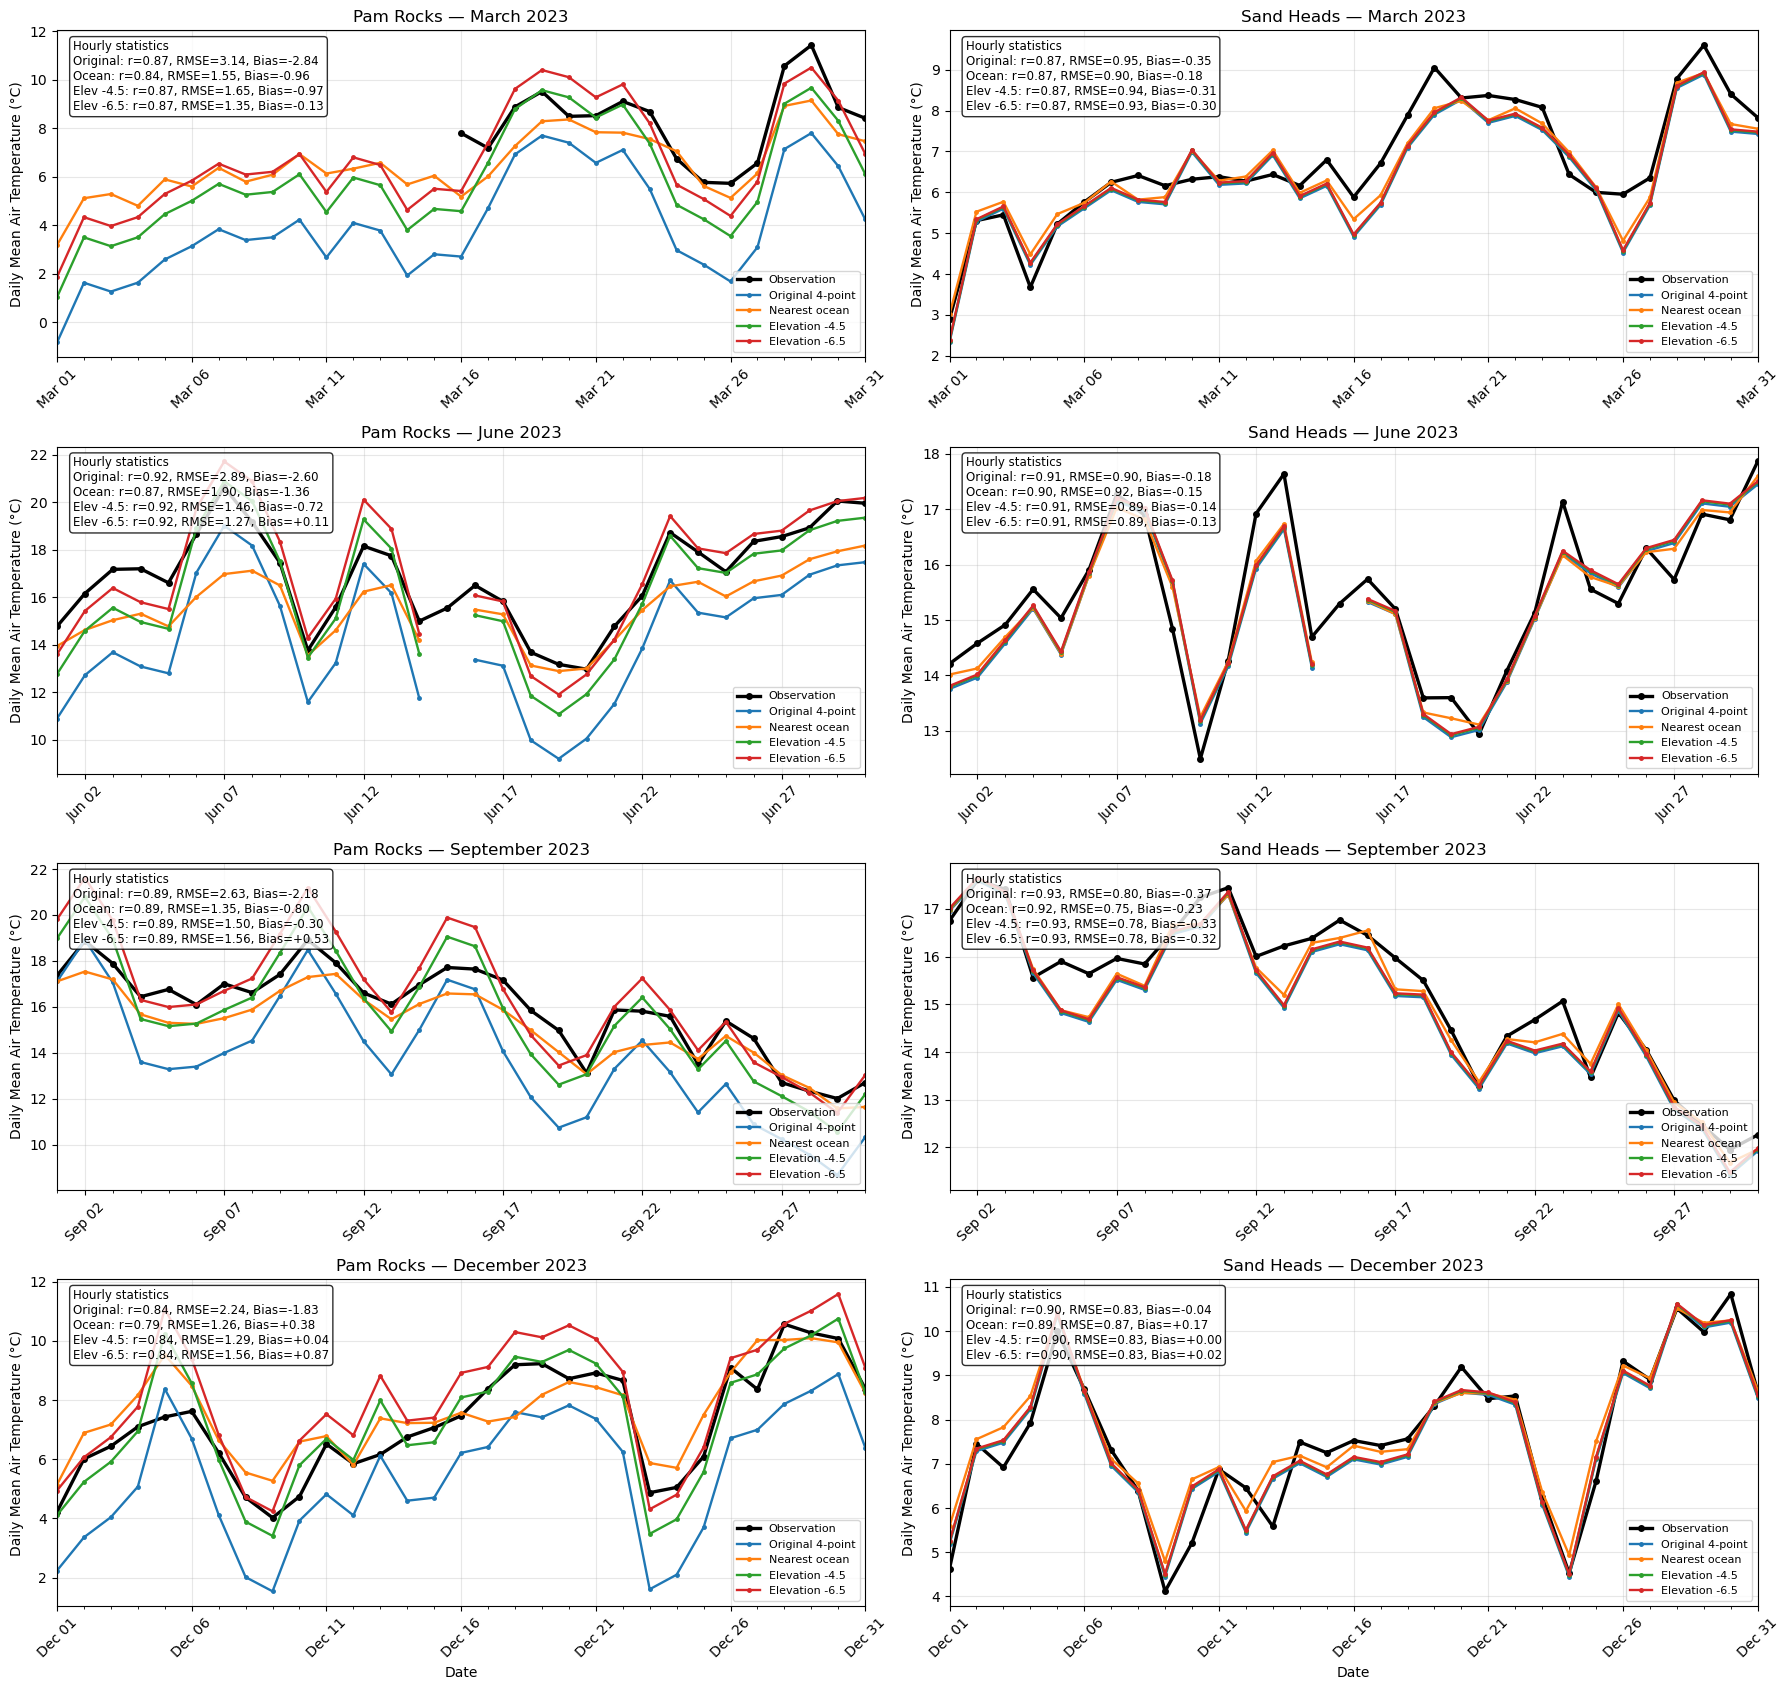

In [7]:
# ============================================================
# CaSR vs Observation
#
# Stations:
#   1. Pam Rocks
#   2. Sand Heads
#
# Months:
#   March, June, September, December 2023
#
# CaSR methods:
#   1. Original 4-point interpolation
#   2. Nearest-ocean correction
#   3. Elevation correction: -4.5 C/km
#   4. Elevation correction: -6.5 C/km
#
# Plot:
#   Daily means
#
# Statistics:
#   Hourly r, RMSE, Bias
# ============================================================


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from pathlib import Path


# ============================================================
# 1. CaSR raw point data
# ============================================================

# Change filename here if your extracted file has a different name
path_casr = (
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Analysis_Fjords/"
    "Data_CaSR/"
    "CaSR_PamRocks_SandHeads_raw_tair_2023.csv"
)


# ============================================================
# 2. Observation folders
# ============================================================

pam_obs_dir = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Data_Pam_Rock_2008_2014"
)

sand_obs_dir = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_forcing_vs_observation/"
    "Data_sandheads_2008_2024"
)


# ============================================================
# 3. Months
# ============================================================

months = {
    3: "March",
    6: "June",
    9: "September",
    12: "December",
}

year = 2023


# ============================================================
# 4. Observation files
# ============================================================

obs_paths = {
    "Pam Rocks": {
        month: (
            pam_obs_dir
            / f"en_climate_hourly_BC_10459NN_{month:02d}-{year}_P1H.csv"
        )
        for month in months
    },

    "Sand Heads": {
        month: (
            sand_obs_dir
            / f"en_climate_hourly_BC_1107010_{month:02d}-{year}_P1H.csv"
        )
        for month in months
    },
}


# ============================================================
# 5. Original interpolation weights
# ============================================================

weights_original = {

    "Pam Rocks": np.array([
        0.8099528243,   # P1
        0.0239716401,   # P2
        0.1613015984,   # P3
        0.0047739371,   # P4
    ]),

    "Sand Heads": np.array([
        0.5675647174,   # P1
        0.1233862179,   # P2
        0.2538607824,   # P3
        0.0551882822,   # P4
    ]),
}


# ============================================================
# 6. Elevation of original four CaSR points
#
# unit: m
# ============================================================

elevation_m = {

    "Pam Rocks": np.array([
        37.89683151245117,      # P1
        26.020360946655273,     # P2
        62.28487777709961,      # P3
        55.567787170410156,     # P4
    ]) * 10.0,

    "Sand Heads": np.array([
        0.0,                    # P1
        5.031019004175796e-13,  # P2
        2.917071580886841,      # P3
        2.2472474575042725,     # P4
    ]) * 10.0,
}


# ============================================================
# 7. Target station elevation
#
# Currently assumed sea level.
#
# If you later have exact station elevations,
# just change these two numbers.
# ============================================================

station_elevation_m = {
    "Pam Rocks": 0.0,
    "Sand Heads": 0.0,
}


# ============================================================
# 8. Column names in the raw CaSR CSV
# ============================================================

point_columns = {

    "Pam Rocks": [
        "PamRocks_P1_y58x36",
        "PamRocks_P2_y57x36",
        "PamRocks_P3_y58x37",
        "PamRocks_P4_y57x37",
    ],

    "Sand Heads": [
        "SandHeads_P1_y54x34",
        "SandHeads_P2_y55x34",
        "SandHeads_P3_y54x35",
        "SandHeads_P4_y55x35",
    ],
}


# ============================================================
# 9. Nearest-ocean correction
#
# Pam Rocks:
#   corrected pure-ocean point = y57 x34
#   weight = 1
#
# Sand Heads:
#   pure-ocean interpolation uses P1 and P2
# ============================================================

pam_ocean_col = "PamRocks_corrected_y57x34"

sand_ocean_weights = np.array([
    0.8214254999,
    0.1785745001,
])


# ============================================================
# 10. Read raw CaSR data
# ============================================================

casr = pd.read_csv(path_casr)

casr["time_counter"] = pd.to_datetime(
    casr["time_counter"]
)

casr = (
    casr
    .set_index("time_counter")
    .sort_index()
)


# ============================================================
# 11. Make all model columns numeric
# ============================================================

all_model_columns = (
    point_columns["Pam Rocks"]
    + [pam_ocean_col]
    + point_columns["Sand Heads"]
)

for col in all_model_columns:

    casr[col] = pd.to_numeric(
        casr[col],
        errors="coerce",
    )


# ============================================================
# 12. Convert CaSR tair to Celsius IN MEMORY
#
# Raw CSV remains unchanged.
#
# If mean temperature is > 100,
# tair is assumed to be Kelvin.
# ============================================================

sample_mean = (
    casr[all_model_columns]
    .stack()
    .mean()
)

if sample_mean > 100:

    print(
        "CaSR tair appears to be Kelvin."
        " Converting to Celsius for analysis."
    )

    casr[all_model_columns] = (
        casr[all_model_columns]
        - 273.15
    )

else:

    print(
        "CaSR tair appears to already be Celsius."
    )


# ============================================================
# 13. Helper:
# weighted sum of four columns
# ============================================================

def weighted_four_points(df, columns, weights):

    result = 0.0

    for col, weight in zip(
        columns,
        weights
    ):

        result = (
            result
            + df[col] * weight
        )

    return result


# ============================================================
# 14. ORIGINAL 4-point interpolation
# ============================================================

for station in [
    "Pam Rocks",
    "Sand Heads",
]:

    short = (
        "PamRocks"
        if station == "Pam Rocks"
        else "SandHeads"
    )

    casr[
        f"{short}_original"
    ] = weighted_four_points(
        casr,
        point_columns[station],
        weights_original[station],
    )


# ============================================================
# 15. NEAREST-OCEAN correction
# ============================================================

# Pam Rocks:
# one pure-ocean point
casr["PamRocks_ocean"] = (
    casr[pam_ocean_col]
)


# Sand Heads:
# corrected interpolation using only P1 and P2
casr["SandHeads_ocean"] = (
    sand_ocean_weights[0]
    * casr["SandHeads_P1_y54x34"]

    +

    sand_ocean_weights[1]
    * casr["SandHeads_P2_y55x34"]
)


# ============================================================
# 16. Elevation correction function
#
# lapse_rate:
#     -4.5 C/km
#     -6.5 C/km
#
# Formula:
#
# T_station =
#     T_grid
#     + lapse_rate *
#       (z_station - z_grid) / 1000
#
#
# Because lapse_rate is negative,
# when the station is below the CaSR grid point:
#
# T_station > T_grid
#
# Example:
#
# grid elevation = 100 m
# station = 0 m
# lapse rate = -6.5 C/km
#
# correction =
# -6.5 * (0 - 100) / 1000
# = +0.65 C
# ============================================================

def elevation_corrected_weighted(
    df,
    columns,
    weights,
    grid_elevations,
    station_elevation,
    lapse_rate,
):

    result = 0.0

    for (
        col,
        weight,
        grid_z,
    ) in zip(
        columns,
        weights,
        grid_elevations,
    ):

        corrected_temperature = (
            df[col]
            + lapse_rate
            * (
                station_elevation
                - grid_z
            )
            / 1000.0
        )

        result = (
            result
            + corrected_temperature
            * weight
        )

    return result


# ============================================================
# 17. Elevation corrections
# ============================================================

for station in [
    "Pam Rocks",
    "Sand Heads",
]:

    short = (
        "PamRocks"
        if station == "Pam Rocks"
        else "SandHeads"
    )


    # --------------------------------------------------------
    # -4.5 C/km
    # --------------------------------------------------------

    casr[
        f"{short}_elev45"
    ] = elevation_corrected_weighted(

        df=casr,

        columns=point_columns[station],

        weights=weights_original[station],

        grid_elevations=elevation_m[station],

        station_elevation=(
            station_elevation_m[station]
        ),

        lapse_rate=-4.5,
    )


    # --------------------------------------------------------
    # -6.5 C/km
    # --------------------------------------------------------

    casr[
        f"{short}_elev65"
    ] = elevation_corrected_weighted(

        df=casr,

        columns=point_columns[station],

        weights=weights_original[station],

        grid_elevations=elevation_m[station],

        station_elevation=(
            station_elevation_m[station]
        ),

        lapse_rate=-6.5,
    )


# ============================================================
# 18. Print weighted mean elevations
#
# Just useful to check how large the correction is.
# ============================================================

for station in [
    "Pam Rocks",
    "Sand Heads",
]:

    mean_z = np.sum(
        weights_original[station]
        * elevation_m[station]
    )

    print(
        f"{station}: "
        f"weighted CaSR elevation = "
        f"{mean_z:.3f} m"
    )


# ============================================================
# 19. Read observation
# ============================================================

def read_obs(path):

    df = pd.read_csv(path)

    df["Date/Time (UTC)"] = pd.to_datetime(
        df["Date/Time (UTC)"]
    )

    df["Temp (°C)"] = pd.to_numeric(
        df["Temp (°C)"],
        errors="coerce",
    )

    df = (
        df
        .set_index("Date/Time (UTC)")
        .sort_index()
    )

    return df["Temp (°C)"]


# ============================================================
# 20. Read all observations
# ============================================================

observations = {}

for station in obs_paths:

    observations[station] = {}

    for month, path in obs_paths[station].items():

        print(
            f"Reading observation: "
            f"{station}, "
            f"{months[month]} -> {path}"
        )

        observations[station][month] = (
            read_obs(path)
        )


# ============================================================
# 21. Statistics
#
# Hourly data
#
# r
# RMSE
# Bias = Model - Observation
# ============================================================

def calculate_statistics(obs, model):

    compare = pd.concat(
        [
            obs.rename("OBS"),
            model.rename("MODEL"),
        ],
        axis=1,
    )

    compare = compare.dropna()


    if len(compare) < 2:

        return (
            np.nan,
            np.nan,
            np.nan,
            0,
        )


    r = compare["OBS"].corr(
        compare["MODEL"]
    )


    rmse = np.sqrt(
        np.mean(
            (
                compare["MODEL"]
                - compare["OBS"]
            ) ** 2
        )
    )


    bias = np.mean(
        compare["MODEL"]
        - compare["OBS"]
    )


    return (
        r,
        rmse,
        bias,
        len(compare),
    )


# ============================================================
# 22. Model columns
# ============================================================

model_columns = {

    "Pam Rocks": {
        "Original 4-point":
            "PamRocks_original",

        "Nearest ocean":
            "PamRocks_ocean",

        "Elevation -4.5":
            "PamRocks_elev45",

        "Elevation -6.5":
            "PamRocks_elev65",
    },


    "Sand Heads": {
        "Original 4-point":
            "SandHeads_original",

        "Nearest ocean":
            "SandHeads_ocean",

        "Elevation -4.5":
            "SandHeads_elev45",

        "Elevation -6.5":
            "SandHeads_elev65",
    },
}


# ============================================================
# 23. Plot
#
# rows    = 4 months
# columns = 2 stations
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(18, 17),
    sharey=False,
)


stations = [
    "Pam Rocks",
    "Sand Heads",
]


# ============================================================
# 24. Loop over months and stations
# ============================================================

for row, month in enumerate(months):

    month_name = months[month]


    start_time = pd.Timestamp(
        year=year,
        month=month,
        day=1,
    )


    end_time = (
        start_time
        + pd.offsets.MonthEnd(1)
        + pd.Timedelta(
            hours=23,
            minutes=59,
        )
    )


    for col, station in enumerate(stations):

        ax = axes[row, col]


        # ----------------------------------------------------
        # Observation: hourly
        # ----------------------------------------------------

        obs_hourly = (
            observations[station][month]
            .loc[start_time:end_time]
        )


        # ----------------------------------------------------
        # Observation: daily
        # ----------------------------------------------------

        obs_daily = (
            obs_hourly
            .resample("1D")
            .mean()
        )


        # ----------------------------------------------------
        # Plot observation
        # ----------------------------------------------------

        ax.plot(
            obs_daily.index,
            obs_daily.values,
            linewidth=2.4,
            marker="o",
            markersize=4,
            color="k",
            label="Observation",
        )


        # ----------------------------------------------------
        # Statistics text
        # ----------------------------------------------------

        stats_lines = [
            "Hourly statistics",
        ]


        # ----------------------------------------------------
        # Plot four CaSR methods
        # ----------------------------------------------------

        for method_name, model_col in (
            model_columns[station].items()
        ):

            # Hourly model data
            model_hourly = (
                casr[model_col]
                .loc[start_time:end_time]
            )


            # Daily mean for plot
            model_daily = (
                model_hourly
                .resample("1D")
                .mean()
            )


            # Plot
            ax.plot(
                model_daily.index,
                model_daily.values,
                linewidth=1.7,
                marker="o",
                markersize=2.5,
                label=method_name,
            )


            # Hourly statistics
            r, rmse, bias, n = (
                calculate_statistics(
                    obs_hourly,
                    model_hourly,
                )
            )


            # shorter labels in statistics box
            if method_name == "Original 4-point":
                stat_name = "Original"

            elif method_name == "Nearest ocean":
                stat_name = "Ocean"

            elif method_name == "Elevation -4.5":
                stat_name = "Elev -4.5"

            else:
                stat_name = "Elev -6.5"


            stats_lines.append(
                f"{stat_name}: "
                f"r={r:.2f}, "
                f"RMSE={rmse:.2f}, "
                f"Bias={bias:+.2f}"
            )


        # ----------------------------------------------------
        # Statistics textbox
        # ----------------------------------------------------

        ax.text(
            0.02,
            0.97,
            "\n".join(stats_lines),

            transform=ax.transAxes,

            fontsize=8.5,

            verticalalignment="top",

            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.82,
            ),
        )


        # ----------------------------------------------------
        # Title
        # ----------------------------------------------------

        ax.set_title(
            f"{station} — {month_name} {year}",
            fontsize=12,
        )


        # ----------------------------------------------------
        # Axis
        # ----------------------------------------------------

        ax.set_ylabel(
            "Daily Mean Air Temperature (°C)"
        )


        ax.grid(
            True,
            alpha=0.3,
        )


        ax.set_xlim(
            start_time.normalize(),
            end_time.normalize(),
        )


        # Major ticks every 5 days
        ax.xaxis.set_major_locator(
            mdates.DayLocator(
                interval=5
            )
        )


        # Minor ticks every day
        ax.xaxis.set_minor_locator(
            mdates.DayLocator(
                interval=1
            )
        )


        ax.xaxis.set_major_formatter(
            mdates.DateFormatter(
                "%b %d"
            )
        )


        ax.tick_params(
            axis="x",
            rotation=45,
        )


        # ----------------------------------------------------
        # Legend
        # ----------------------------------------------------

        ax.legend(
            loc="lower right",
            fontsize=8,
        )


# ============================================================
# 25. X labels
# ============================================================

axes[-1, 0].set_xlabel(
    "Date"
)

axes[-1, 1].set_xlabel(
    "Date"
)




# ============================================================
# 27. Layout
# ============================================================

plt.tight_layout()


# ============================================================
# 28. Show
# ============================================================

plt.show()

Both land-sea surface (bottom?) and altitude cause the difference. Which correction (Ocean only and 6.5K/km) is better depends on season and what we expect. Ocean-grid correction has better correlation but altitude-balance correction has better bias.